# Data Cleaning Exercise
Group: 2

Team: Elias Grünbacher, Peter Kovacs, Mario Lagger

## Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Load Data

Link to data source: (https://www.kaggle.com/datasets/lokeshparab/amazon-products-dataset)

In [2]:
data=pd.read_csv('amazon-products-electronics-sales-2023.csv')

## Understand the Data

View the first few rows, get summary statistics and check data types

In [3]:
data.head()

,name,main_category,sub_category,image,link,ratings,no_of_ratings,discount_price,actual_price
0,"Redmi 10 Power (Power Black, 8GB RAM, 128GB St...","tv, audio & cameras",All Electronics,https://m.media-amazon.com/images/I/81eM15lVcJ...,https://www.amazon.in/Redmi-Power-Black-128GB-...,4.0,965,"₹10,999","₹18,999"
1,"OnePlus Nord CE 2 Lite 5G (Blue Tide, 6GB RAM,...","tv, audio & cameras",All Electronics,https://m.media-amazon.com/images/I/71AvQd3Vzq...,https://www.amazon.in/OnePlus-Nord-Lite-128GB-...,4.3,"113,956","₹18,999","₹19,999"
2,OnePlus Bullets Z2 Bluetooth Wireless in Ear E...,"tv, audio & cameras",All Electronics,https://m.media-amazon.com/images/I/51UhwaQXCp...,https://www.amazon.in/Oneplus-Bluetooth-Wirele...,4.2,"90,304","₹1,999","₹2,299"
3,"Samsung Galaxy M33 5G (Mystique Green, 6GB, 12...","tv, audio & cameras",All Electronics,https://m.media-amazon.com/images/I/81I3w4J6yj...,https://www.amazon.in/Samsung-Mystique-Storage...,4.1,"24,863","₹15,999","₹24,999"
4,"OnePlus Nord CE 2 Lite 5G (Black Dusk, 6GB RAM...","tv, audio & cameras",All Electronics,https://m.media-amazon.com/images/I/71V--WZVUI...,https://www.amazon.in/OnePlus-Nord-Black-128GB...,4.3,"113,956","₹18,999","₹19,999"


In [4]:
data.shape

(9600, 9)

We confirm that the datatypes are correct now.

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9600 entries, 0 to 9599
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   name            9600 non-null   object
 1   main_category   9600 non-null   object
 2   sub_category    9600 non-null   object
 3   image           9600 non-null   object
 4   link            9600 non-null   object
 5   ratings         9505 non-null   object
 6   no_of_ratings   9505 non-null   object
 7   discount_price  9116 non-null   object
 8   actual_price    9530 non-null   object
dtypes: object(9)
memory usage: 675.1+ KB


## Handle Missing Data

In [6]:
data.isnull().sum()

name                0
main_category       0
sub_category        0
image               0
link                0
ratings            95
no_of_ratings      95
discount_price    484
actual_price       70
dtype: int64

We delete the missing values of ratings and actual_price because we have enough other remaining datarecords for our purposes. 

In [7]:
data = data.dropna(subset=['ratings', 'actual_price'])

In [8]:
data.isnull().sum()

name                0
main_category       0
sub_category        0
image               0
link                0
ratings             0
no_of_ratings       0
discount_price    409
actual_price        0
dtype: int64

In [9]:
data.shape

(9435, 9)


We replace the discount_price with the actual_price if it the value is missing because we assume that the price is not discounted. 

In [10]:
data["discount_price"] = data["discount_price"].fillna(data["actual_price"])

In [11]:
data.isnull().sum()

name              0
main_category     0
sub_category      0
image             0
link              0
ratings           0
no_of_ratings     0
discount_price    0
actual_price      0
dtype: int64

## Handle Duplicates

We count how many fully duplicated rows exist

In [12]:
print(data.duplicated().sum())

0


We have no duplicate rows, so no removal is needed. 

## Handle Incorrect Data Types

### Price
Remove the corrupted currency symbol and commas, then convert prices to floats.

In [13]:
for column in ["discount_price", "actual_price"]:
    data[column] = pd.to_numeric(
        data[column].str.replace(r"[^\d.]", "", regex=True),
        errors="coerce"
    )

### Ratings

In [14]:
print(data["ratings"].unique())

['4.0' '4.3' '4.2' '4.1' '3.9' '4.6' '3.8' 'Get' '4.4' '3.5' '3.7' '4.5'
 '3.3' '3.6' '3.4' '3.2' '2.9' '4.7' '5.0' '2.5' '2.8' '4.8' '3.1' '3.0'
 '2.3' '2.7' '2.4' '4.9' '1.7' '1.5' '2.6' '1.8' '1.3' '2.1' '1.9' '2.2'
 '1.0' '1.4' '2.0']


We convert invalid values such as 'Get' to NaN.

In [15]:
data["ratings"] = pd.to_numeric(data["ratings"], errors="coerce")

Remove thousands separators before converting review counts to integers.

In [16]:
data["no_of_ratings"] = pd.to_numeric(
    data["no_of_ratings"].str.replace(",", "", regex=False),
    errors="coerce"
)

Rows that still contain invalid numeric values in essential columns are removed.

In [17]:
data = data.dropna(subset=["ratings", "no_of_ratings", "discount_price", "actual_price"])

Use an integer dtype for review counts because decimals are not meaningful there.

In [18]:
data["no_of_ratings"] = data["no_of_ratings"].astype("int64")

In [19]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9411 entries, 0 to 9599
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   name            9411 non-null   object 
 1   main_category   9411 non-null   object 
 2   sub_category    9411 non-null   object 
 3   image           9411 non-null   object 
 4   link            9411 non-null   object 
 5   ratings         9411 non-null   float64
 6   no_of_ratings   9411 non-null   int64  
 7   discount_price  9411 non-null   float64
 8   actual_price    9411 non-null   float64
dtypes: float64(3), int64(1), object(5)
memory usage: 735.2+ KB


## Convert currency to EUR
We convert the currency to EUR according to the current exchange rate for simplicity. 

In [20]:
inr_to_eur_rate = 0.011
price_columns = ["discount_price", "actual_price"]

data[price_columns] = data[price_columns] * inr_to_eur_rate
data[price_columns] = data[price_columns].round(2)

In [21]:
data[price_columns].head()

,discount_price,actual_price
0,120.99,208.99
1,208.99,219.99
2,21.99,25.29
3,175.99,274.99
4,208.99,219.99


## Handle Outliers

In [22]:
outlier_columns = ["discount_price", "actual_price", "no_of_ratings"]

data[outlier_columns + ["ratings"]].describe()

,discount_price,actual_price,no_of_ratings,ratings
count,9411.000000,9411.000000,9411.000000,9411.000000
mean,33.013289,54.885714,8856.542132,4.078440
std,98.987136,133.479843,28152.594316,0.377687
min,0.110000,0.220000,1.000000,1.000000
25%,3.290000,9.340000,236.000000,3.900000
50%,6.260000,16.490000,1172.000000,4.100000
75%,17.260000,36.910000,5080.500000,4.300000
max,1648.900000,1781.990000,437651.000000,5.000000


### Print outliers according to IQR rule
We print the amount of outliers that we identify according to the IQR rule. We have decided not to remove the datarecords with outliers because the prices of the products in our dataset have high fluctuations. E.g. a phone case is much cheaper than a phone

In [23]:
for column in outlier_columns:
    q1 = data[column].quantile(0.25)
    q3 = data[column].quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outlier_count = ((data[column] < lower_bound) | (data[column] > upper_bound)).sum()
    print(f"{column}: {outlier_count} outliers")

discount_price: 1238 outliers
actual_price: 1238 outliers
no_of_ratings: 1345 outliers


### Remove impossible values
Ratings are valid only on the Amazon 1-5 scale

In [24]:
data = data[(data["ratings"] >= 1) & (data["ratings"] <= 5)]

A discounted price should not be higher than the actual price.
If that happens after cleaning, align the discount price with the actual price.

In [25]:
data.loc[data["discount_price"] > data["actual_price"], "discount_price"] = data["actual_price"]

In [26]:
data[outlier_columns + ["ratings"]].describe()

,discount_price,actual_price,no_of_ratings,ratings
count,9411.000000,9411.000000,9411.000000,9411.000000
mean,33.013289,54.885714,8856.542132,4.078440
std,98.987136,133.479843,28152.594316,0.377687
min,0.110000,0.220000,1.000000,1.000000
25%,3.290000,9.340000,236.000000,3.900000
50%,6.260000,16.490000,1172.000000,4.100000
75%,17.260000,36.910000,5080.500000,4.300000
max,1648.900000,1781.990000,437651.000000,5.000000


In [27]:
data.loc[data["no_of_ratings"].idxmax()]

name              Amazon Basics High-Speed HDMI Cable - 10 Feet ...
main_category                                   tv, audio & cameras
sub_category                                        All Electronics
image             https://m.media-amazon.com/images/W/IMAGERENDE...
link              https://www.amazon.in/AmazonBasics-High-Speed-...
ratings                                                         4.4
no_of_ratings                                                437651
discount_price                                                 4.17
actual_price                                                  10.94
Name: 470, dtype: object

In [28]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9411 entries, 0 to 9599
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   name            9411 non-null   object 
 1   main_category   9411 non-null   object 
 2   sub_category    9411 non-null   object 
 3   image           9411 non-null   object 
 4   link            9411 non-null   object 
 5   ratings         9411 non-null   float64
 6   no_of_ratings   9411 non-null   int64  
 7   discount_price  9411 non-null   float64
 8   actual_price    9411 non-null   float64
dtypes: float64(3), int64(1), object(5)
memory usage: 993.3+ KB


## Visualize Data

In [29]:
visual_data = data.copy()
visual_data["discount_amount"] = visual_data["actual_price"] - visual_data["discount_price"]
visual_data["discount_percent"] = np.where(
    visual_data["actual_price"] > 0,
    (visual_data["discount_amount"] / visual_data["actual_price"]) * 100,
    0
)

sns.set_theme(style="whitegrid", palette="Set2")


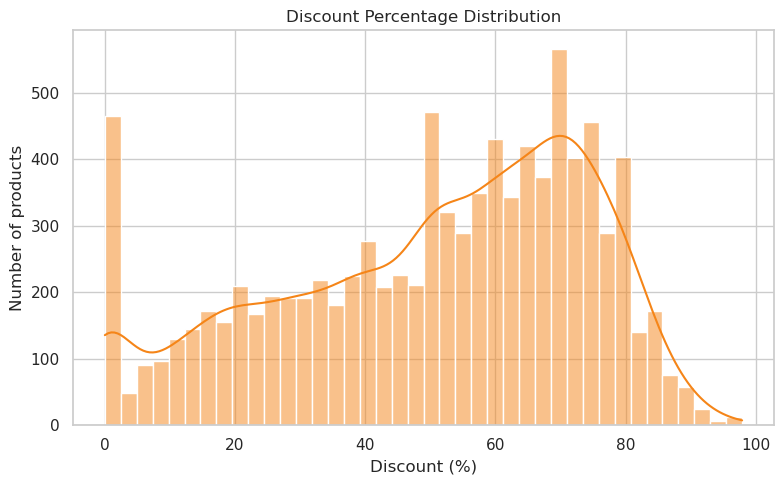

In [30]:
plt.figure(figsize=(8, 5))
sns.histplot(visual_data["discount_percent"], bins=40, kde=True, color="#F58518")
plt.title("Discount Percentage Distribution")
plt.xlabel("Discount (%)")
plt.ylabel("Number of products")
plt.tight_layout()
plt.show()


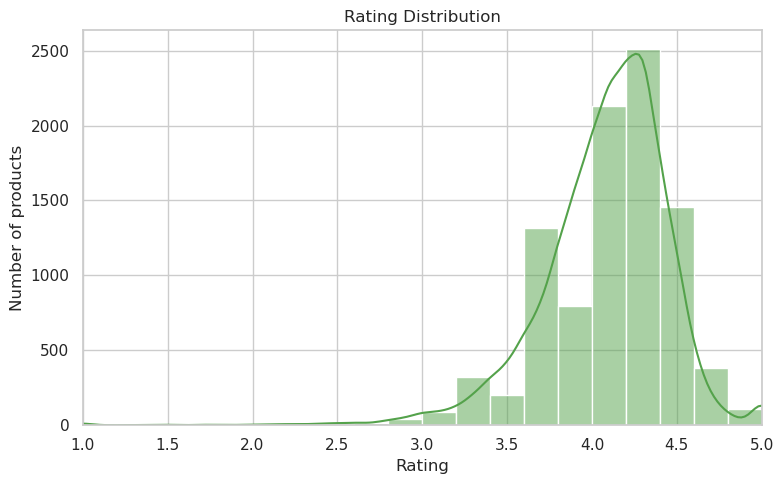

In [31]:
plt.figure(figsize=(8, 5))
sns.histplot(visual_data["ratings"], bins=20, kde=True, color="#54A24B")
plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Number of products")
plt.xlim(1, 5)
plt.tight_layout()
plt.show()


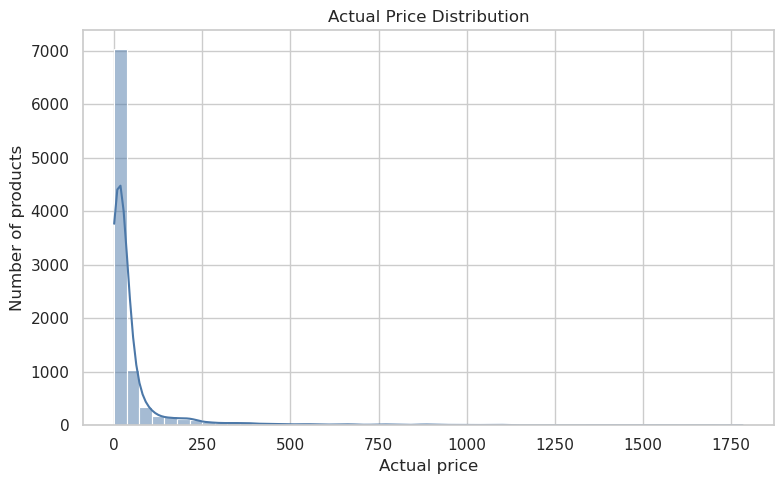

In [32]:
plt.figure(figsize=(8, 5))
sns.histplot(visual_data["actual_price"], bins=50, kde=True, color="#4C78A8")
plt.title("Actual Price Distribution")
plt.xlabel("Actual price")
plt.ylabel("Number of products")
plt.tight_layout()
plt.show()

## Save Cleaned Data

In [33]:
output_file = "cleaned-amazon-products-electronics-sales-2023.csv"

data.to_csv(output_file, index=False)

print(f"Cleaned data saved to {output_file}")

Cleaned data saved to cleaned-amazon-products-electronics-sales-2023.csv
